In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, plot_roc_curve
import shap

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Load data
file = "../feature_tsv/feature_pruned_withNA.tsv"
df = pd.read_csv(file, delimiter="\t")
df

,PPARD_rs4713859,LRP5_rs3736228,CSNK1A1_rs10476909,CSNK1A1_rs1379544,CSNK1A1_rs447950,CSNK1A1_rs414582,CSNK1A1_rs3733658,CSNK1A1_rs2400891,CSNK1A1_rs10062536,LRP5_rs4988300,...,CADD_max_PPARD,CADD_max_PRKCD,SEX_N_MALE,RADIATION_STATUS_N,AGE_MTX_INITIATION_YEAR,PC1,PC2,PC3,PC4,phenotype
0,0,0,1,1,0,0,1,1,0,0,...,13.94,6.272,0.0,0.0,10.983562,-0.008191,-0.018680,0.005815,-0.007583,0
1,0,1,1,0,1,0,0,0,0,1,...,13.94,6.272,0.0,0.0,7.997268,-0.008189,-0.018549,0.008773,-0.008295,0
2,0,0,0,2,0,0,2,2,0,0,...,13.94,12.370,1.0,0.0,2.528767,-0.008197,-0.018704,0.008160,-0.007941,0
3,0,0,0,1,1,1,1,1,1,0,...,13.94,6.272,1.0,1.0,16.498630,-0.000459,-0.013120,0.008233,0.012657,0
4,0,0,1,1,0,0,2,2,0,1,...,13.94,6.272,0.0,0.0,1.802740,-0.008050,-0.019170,0.007359,-0.009525,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,0,0,1,2,0,0,2,2,0,2,...,13.94,8.324,0.0,0.0,4.082192,-0.006296,-0.017952,0.009310,0.002128,0
274,0,0,0,0,1,1,0,0,1,2,...,13.94,6.272,1.0,0.0,8.972603,-0.004892,-0.016423,0.009984,0.006774,0
275,0,0,0,0,1,0,1,1,0,0,...,13.94,12.370,0.0,0.0,8.027322,-0.007780,-0.018166,0.007905,-0.005000,0
276,0,0,0,1,1,0,1,1,0,0,...,13.94,12.370,1.0,0.0,7.297814,-0.007948,-0.019062,0.008278,-0.009083,0


In [3]:
#check NA
df.isna().sum().sum()

160

In [4]:
# Check for None
df.applymap(lambda x: x=="").sum().sum()

0

In [5]:
# Split Data 
X_train, X_test, y_train, y_test = train_test_split(df.drop('phenotype', axis=1), df["phenotype"], test_size=0.2, random_state=0)

In [6]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import GridSearchCV

# Initialize XGBoost classifier
clf = xgb.XGBClassifier(objective="binary:logistic", random_state=0, eval_metric="auc" )

# Hyperparameter grid
params = {
#     'scale_pos_weight': [2.22],
#     'n_estimators': [10, 40, 50, 60, 100, 110],
#     'max_depth': [np.arange(2, 7, 1)],
#     'learning_rate': [ 0.3, 0.4, 0.5, 0.6, 0.7],
#     'alpha': [0, 0.5, 1],
#     'lambda': [1, 1.5, 2],
    'scale_pos_weight': [2.22],
    'n_estimators': [10],
    'max_depth': [3],
    'learning_rate': [0.5],
    'alpha': [0],
    'lambda': [1.5]
    
}

# Perform Grid Search
grid_search = GridSearchCV(clf, params, cv=5, n_jobs=-1, scoring="roc_auc")
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best ROC AUC Score: {best_score}")


Best parameters: {'alpha': 0, 'lambda': 1.5, 'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 10, 'scale_pos_weight': 2.22}
Best ROC AUC Score: 0.6235873803615739


In [7]:
grid_search.best_params_

{'alpha': 0,
 'lambda': 1.5,
 'learning_rate': 0.5,
 'max_depth': 3,
 'n_estimators': 10,
 'scale_pos_weight': 2.22}

#### Save the result

In [12]:
best_model_gbdt_withNA = grid_search.best_estimator_
%store best_model_gbdt_withNA

Stored 'best_model_gbdt_withNA' (XGBClassifier)


In [13]:
%store -r best_model_gbdt_withNA

#### Feature Importance

In [14]:
def plot_top_feature_importance(importances, column_names, top_n=20):
         feature_important_series = pd.Series(importances, index=column_names)
         
         # Sort and take the top_n features
         sorted_importances = feature_important_series.sort_values(ascending=False)[0:top_n + 1].iloc[::-1]
         
         # Normalize 
         sorted_importances = 100.0 * (sorted_importances/sorted_importances.max())
         
         plt.figure(figsize=(12,8))
         sorted_importances.plot(kind="barh")
         plt.xlabel('Relative Importance')
         plt.title(f'Top {top_n} Variable Importance')
         plt.tight_layout()

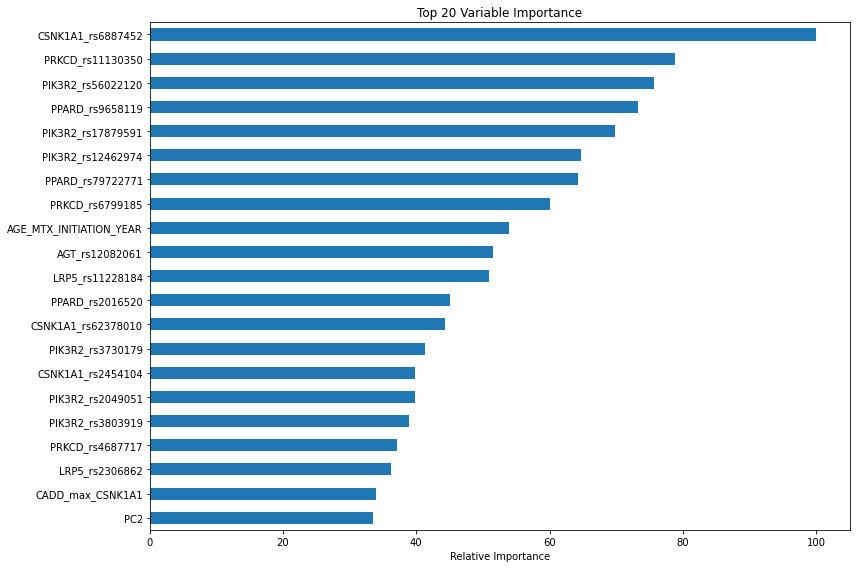

In [15]:
feature_importance = best_model_gbdt_withNA.feature_importances_
feature_names = df.drop("phenotype", axis=1).columns

top_importance = plot_top_feature_importance(feature_importance, feature_names, 20)
# plt.savefig("../plot/top_importance_withNA_PC.pdf")

Feautre Contributions

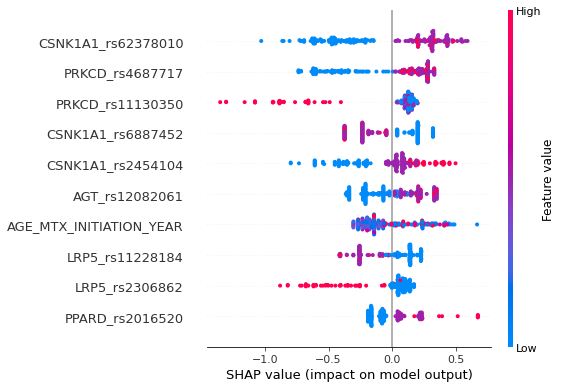

In [39]:
# Compute SHAP values
explainer = shap.Explainer(best_model_gbdt_withNA)
shap_values = explainer(X_train)
shap.summary_plot( shap_values.values, X_train, show=False, max_display=10)

#### Performance Evaluation
* ROC-AUC curve plotting

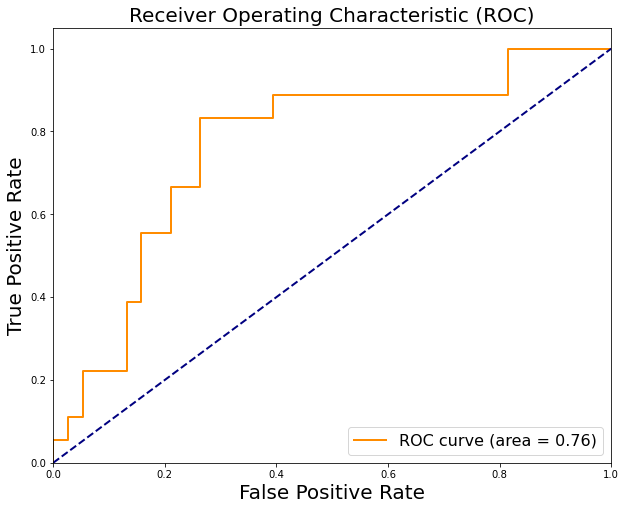

In [16]:
def plot_roc_auc(y_true, y_pred_prob, save_path=None):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.title('Receiver Operating Characteristic (ROC)',fontsize=20)
    plt.legend(loc='lower right', fontsize=16)
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    
if __name__ == "__main__":
    #Predict probabilityes of positive class of each instance
    positive_prob = best_model_gbdt_withNA.predict_proba(X_test)[:,1]

    plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_full_withNA_PC.pdf")

Text(0.5, 15.0, 'Predicted')

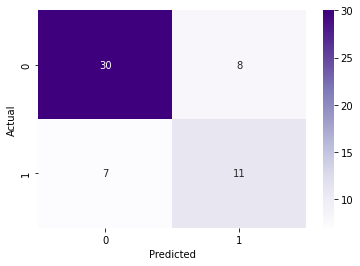

In [17]:
# confusion matrix
y_pred = best_model_gbdt_withNA.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt="d", cmap="Purples", xticklabels=[0,1], yticklabels=[0,1])
plt.ylabel('Actual')
plt.xlabel('Predicted')

npv: 0.81, ppv:0.58, sensitivty0.61, specificity0.79, f1 score0.59


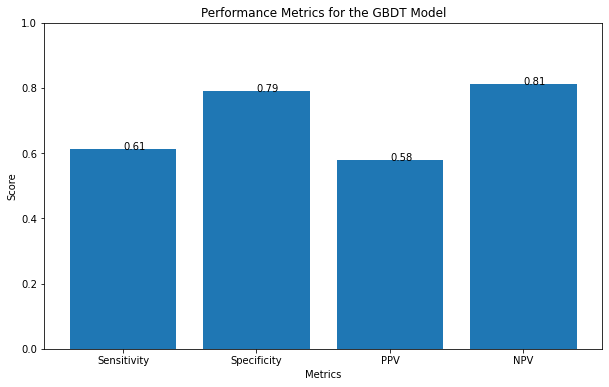

In [18]:
y_pred = best_model_gbdt_withNA.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# sensitivity aka recall
sensitivity = recall

# specificity
tn, fp, fn, tp = conf.ravel() 
specificity  = tn/(tn+fp)

#ppv 
ppv = tp/(tp+fp)
#npv
npv = tn/(tn+fn)

metrics = [sensitivity, specificity, ppv, npv]
metric_names = ['Sensitivity', 'Specificity', 'PPV', 'NPV']

plt.figure(figsize=(10,6))
plt.bar(metric_names, metrics)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim([0, 1])
plt.title('Performance Metrics for the GBDT Model')
for index, value in enumerate(metrics):
    plt.text(index, value, str(round(value, 2)))
plt.savefig("../plot/GBDT_performance_withNA_PC.pdf")
print(f"npv: {npv:0.2f}, ppv:{ppv:0.2f}, sensitivty{sensitivity:0.2f}, specificity{specificity:0.2f}, f1 score{f1:0.2f}")

#### Ablation Test (without genetic variants)

In [15]:
X_test_ablated = X_test.iloc[:,-7:]
X_train_ablated = X_train.iloc[:,-7:] 

In [16]:
grid_search.fit(X_train_ablated, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='auc', feature_types=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                   

In [17]:
best_model_withNA_ablated_PC = grid_search.best_estimator_  

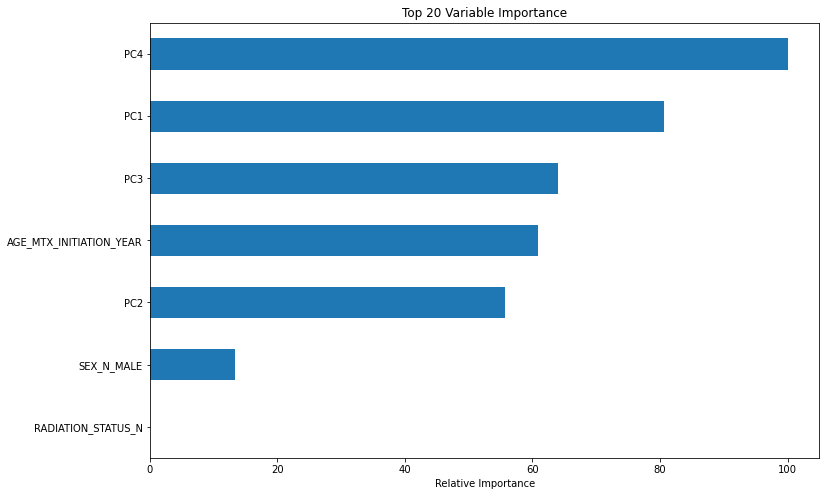

In [35]:
feature_importance = best_model_withNA_ablated_PC.feature_importances_
feature_names = X_train_ablated.columns

top_importance = plot_top_feature_importance(feature_importance, feature_names, 20)
plt.savefig("../plot/top_importance_full_withNA_ablated_PC.pdf")

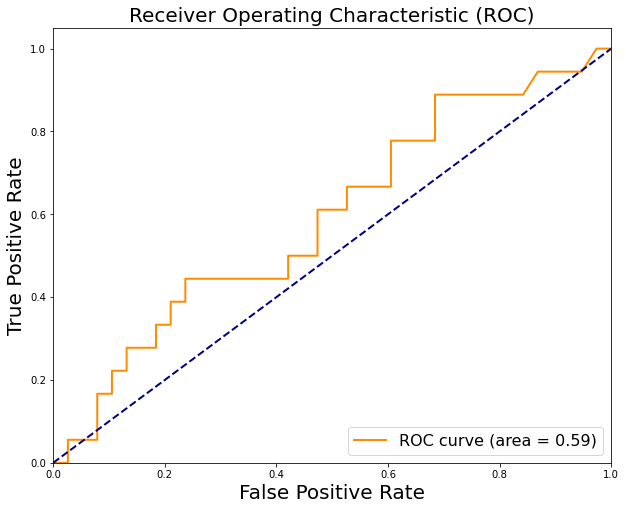

In [19]:
#Predict probabilityes of positive class of each instance
positive_prob = best_model_withNA_ablated_PC.predict_proba(X_test_ablated)[:,1]

plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_ablated_withNA_PC.pdf")

##### Model without PCs

In [27]:
X_test_no_PC = X_test.iloc[:,:-5]
X_train_no_PC = X_train.iloc[:,:-5]

In [29]:
grid_search.fit(X_train_no_PC, y_train)
best_model_withNA_noPC = grid_search.best_estimator_

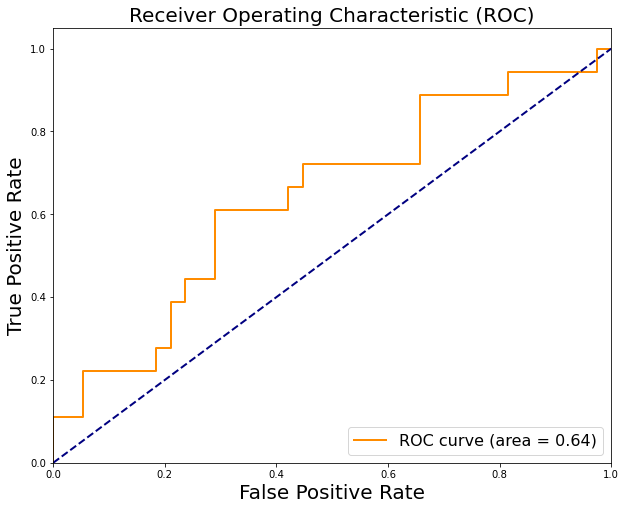

In [32]:
#Predict probabilityes of positive class of each instance
positive_prob = best_model_withNA_noPC.predict_proba(X_test_no_PC)[:,1]

plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_ablated_withNA_noPC.pdf")

##### Manually adjust thte scale_pos_weight metric to 2.22 based on control:case ratio

In [20]:
# clf = xgb.XGBClassifier(objective="binary:logistic", random_state=0, eval_metric='auc')
# # Hyperparameter grid
# params = {
#     'scale_pos_weight': [2.22],
#     'n_estimators': [10],
#     'max_depth': [3],
#     'learning_rate': [0.5],
#     'alpha': [0],
#     'lambda': [1.5]
# }

# # Perform Grid Search
# grid_search = GridSearchCV(clf, params, cv=5, n_jobs=-1, scoring="roc_auc")
# grid_search.fit(X_train , y_train)

# # Get the best parameters and score
# best_params = grid_search.best_params_
# best_score = grid_search.best_score_

# print(f"Best parameters: {best_params}")
# print(f"Best ROC AUC Score: {best_score}")

# test_model = grid_search.best_estimator_

# y_pred = test_model.predict(X_test)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)

# # sensitivity aka recall
# sensitivity = recall

# # specificity
# tn, fp, fn, tp = conf.ravel() 
# specificity  = tn/(tn+fp)

# #ppv 
# ppv = tp/(tp+fp)
# #npv
# npv = tn/(tn+fn)

# metrics = [sensitivity, specificity, ppv, npv]
# metric_names = ['Sensitivity', 'Specificity', 'PPV', 'NPV']

# plt.figure(figsize=(10,6))
# plt.bar(metric_names, metrics)
# plt.xlabel("Metrics")
# plt.ylabel("Score")
# plt.ylim([0, 1])
# plt.title('Performance Metrics for the GBDT Model')
# for index, value in enumerate(metrics):
#     plt.text(index, value, str(round(value, 2)))
# print(f"npv: {npv:0.2f}, ppv:{ppv:0.2f}, sensitivty{sensitivity:0.2f}, specificity{specificity:0.2f}, f1 score{f1:0.2f}")



In [21]:
# #test
# if __name__ == "__main__":
#     #Predict probabilityes of positive class of each instance
#     positive_prob = test_model.predict_proba(X_test)[:,1]

#     plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_full_withNA_PC.pdf")

In [22]:
# #test

# feature_importance = test_model.feature_importances_
# feature_names = df.drop("phenotype", axis=1).columns

# top_importance = plot_top_feature_importance(feature_importance, feature_names, 20)
# plt.savefig("../plot/top_importance_withNA_PC.pdf")
